# Advanced Analysis: Clustering

Clustering von Fällen basierend auf Trace Length und Case Duration


In [ ]:
import pandas as pd
import pm4py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Pfad zur XES-Datei
FILE_PATH = "/Users/titusthamm/Library/Mobile Documents/com~apple~CloudDocs/Masterstudium/3. Semester/Praktikum/1. Assignment/BPI Challenge 2017_1_all/BPI Challenge 2017.xes.gz"
log_df = pm4py.read_xes(FILE_PATH)


Lade Event Log...


/Users/titusthamm/Library/Mobile Documents/com~apple~CloudDocs/Masterstudium/3. Semester/Praktikum/1. Assignment/.venv/lib/python3.13/site-packages/pm4py/utils.py:991: UserWarning: Install the optional requirement `rustxes` to import/export files faster.
  warnings.warn("Install the optional requirement `rustxes` to import/export files faster.")
/Users/titusthamm/Library/Mobile Documents/com~apple~CloudDocs/Masterstudium/3. Semester/Praktikum/1. Assignment/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 31509/31509 [00:17<00:00, 1794.46it/s]


✓ Log geladen: 1,202,267 Events, 31,509 Fälle


In [ ]:
# Berechne Trace Length (Anzahl Events pro Fall)
trace_lengths = log_df.groupby('case:concept:name').size()

# Berechne Case Duration (in Tagen)
case_durations = log_df.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
case_durations['duration_days'] = (case_durations['max'] - case_durations['min']).dt.total_seconds() / (24 * 3600)

# Erstelle Feature DataFrame
features_df = pd.DataFrame({
    'trace_length': trace_lengths,
    'duration_days': case_durations['duration_days']
}).reset_index()

# Entferne NaN-Werte
features_df = features_df.dropna()

print(f"Feature Statistiken")
print(f"Anzahl Fälle: {len(features_df):,}")
print(f"\nTrace Length:")
print(f"  Mean: {features_df['trace_length'].mean():.2f}")
print(f"  Std:  {features_df['trace_length'].std():.2f}")
print(f"  Min:  {features_df['trace_length'].min()}")
print(f"  Max:  {features_df['trace_length'].max()}")
print(f"Case Duration (Tage):")
print(f"  Mean: {features_df['duration_days'].mean():.2f}")
print(f"  Std:  {features_df['duration_days'].std():.2f}")
print(f"  Min:  {features_df['duration_days'].min():.2f}")
print(f"  Max:  {features_df['duration_days'].max():.2f}")


FEATURE SELECTION: TRACE LENGTH & CASE DURATION

--- Feature Statistiken ---
Anzahl Fälle: 31,509

Trace Length:
  Mean: 38.16
  Std:  16.72
  Min:  10
  Max:  180

Case Duration (Tage):
  Mean: 21.90
  Std:  13.17
  Min:  0.00
  Max:  286.07



In [ ]:
# Extrahiere Features für Normalisierung
X = features_df[['trace_length', 'duration_days']].values

# Z-Score Normalisierung
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Erstelle DataFrame mit normalisierten Features
features_normalized = pd.DataFrame(
    X_normalized,
    columns=['trace_length_norm', 'duration_days_norm'],
    index=features_df.index
)

print(f"Normalisierte Feature Statistiken")
print(f"Trace Length:")
print(f"  Mean: {features_normalized['trace_length_norm'].mean():.6f}")
print(f"  Std:  {features_normalized['trace_length_norm'].std():.6f}")
print(f"Duration Days:")
print(f"  Mean: {features_normalized['duration_days_norm'].mean():.6f}")
print(f"  Std:  {features_normalized['duration_days_norm'].std():.6f}")

DATA NORMALIZATION: Z-SCORE

--- Normalisierte Feature Statistiken ---
Trace Length (normalisiert):
  Mean: -0.000000
  Std:  1.000016

Duration Days (normalisiert):
  Mean: -0.000000
  Std:  1.000016



In [ ]:
# K-Means Clustering auf normalisierten Daten
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_normalized)

# Füge Cluster-Labels zum DataFrame hinzu
features_df['cluster'] = cluster_labels

# Cluster-Zentren (in normalisiertem Raum)
centroids_normalized = kmeans.cluster_centers_

# Transformiere Zentren zurück in originalen Raum
centroids_original = scaler.inverse_transform(centroids_normalized)

print(f"Clustering")
print(f"Anzahl Cluster: 4")
print(f"Cluster-Verteilung:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(cluster_labels) * 100
    print(f"Cluster {cluster_id}: {count:,} Fälle ({pct:.2f}%)")

print(f"Cluster-centers")
centroids_df = pd.DataFrame(
    centroids_original,
    columns=['trace_length', 'duration_days']
)
for i, row in centroids_df.iterrows():
    print(f"  Cluster {i}: Trace Length={row['trace_length']:.2f}, Duration={row['duration_days']:.2f} Tage")



CLUSTERING: K-MEANS (k=4)

--- Clustering Ergebnisse ---
Anzahl Cluster: 4

Cluster-Verteilung:
  Cluster 0: 7,418 Fälle (23.54%)
  Cluster 1: 9,729 Fälle (30.88%)
  Cluster 2: 12,456 Fälle (39.53%)
  Cluster 3: 1,906 Fälle (6.05%)

--- Cluster-Zentren (originale Features) ---
  Cluster 0: Trace Length=54.49, Duration=18.92 Tage
  Cluster 1: Trace Length=26.08, Duration=33.40 Tage
  Cluster 2: Trace Length=32.37, Duration=11.14 Tage
  Cluster 3: Trace Length=74.37, Duration=45.34 Tage



VISUALIZATION: CLUSTER SCATTER PLOT


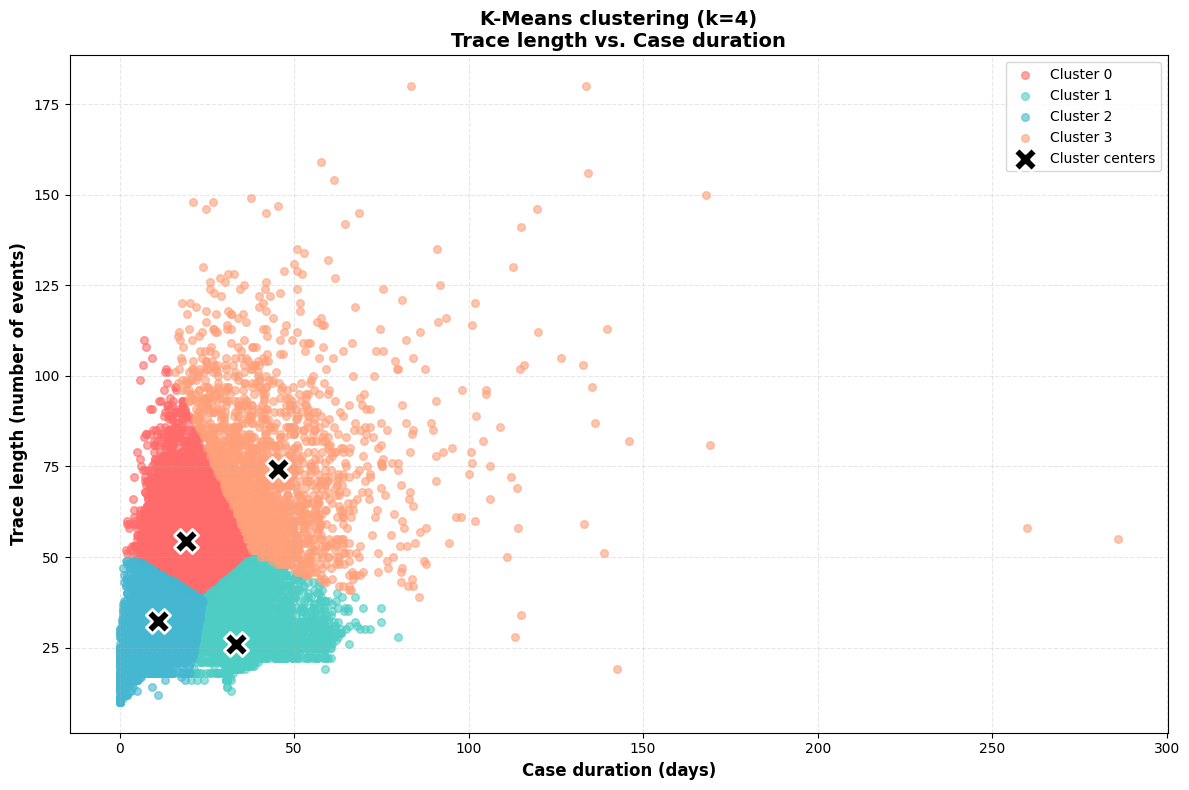


--- Cluster-Charakterisierung ---

Cluster 0:
  Anzahl Fälle: 7,418
  Mean Trace Length: 54.44 Events
  Mean Duration: 18.89 Tage

Cluster 1:
  Anzahl Fälle: 9,729
  Mean Trace Length: 26.08 Events
  Mean Duration: 33.40 Tage

Cluster 2:
  Anzahl Fälle: 12,456
  Mean Trace Length: 32.35 Events
  Mean Duration: 11.13 Tage

Cluster 3:
  Anzahl Fälle: 1,906
  Mean Trace Length: 74.36 Events
  Mean Duration: 45.29 Tage



In [ ]:
plt.figure(figsize=(12, 8))

# Farben für Cluster
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

# Plot für jeden Cluster
for cluster_id in range(4):
    cluster_data = features_df[features_df['cluster'] == cluster_id]
    plt.scatter(
        cluster_data['duration_days'],
        cluster_data['trace_length'],
        c=colors[cluster_id],
        label=cluster_names[cluster_id],
        alpha=0.6,
        s=30
    )

# Plot Cluster-Zentren
plt.scatter(
    centroids_df['duration_days'],
    centroids_df['trace_length'],
    c='black',
    marker='X',
    s=300,
    label='Cluster centers',
    edgecolors='white',
    linewidths=2,
    zorder=10
)

# Labels und Formatierung
plt.xlabel('Case duration (days)', fontsize=12, fontweight='bold')
plt.ylabel('Trace length (number of events)', fontsize=12, fontweight='bold')
plt.title('K-Means clustering (k=4)\nTrace length vs. Case duration', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

for cluster_id in range(4):
    cluster_data = features_df[features_df['cluster'] == cluster_id]
    print(f"\n{cluster_names[cluster_id]}:")
    print(f"  Number of cases: {len(cluster_data):,}")
    print(f"  Mean Trace Length: {cluster_data['trace_length'].mean():.2f} events")
    print(f"  Mean Duration: {cluster_data['duration_days'].mean():.2f} days")


In [ ]:
#2.4.3 Advanced Analysis: Denied Rate Vergleich

# Prüfe ob "A_Denied" irgendwo im Trace vorkommt
print("Suche nach 'A_Denied' im gesamten Trace")
cases_with_denied = log_df[log_df['concept:name'] == 'A_Denied']['case:concept:name'].unique()
print(f"Anzahl Fälle mit 'A_Denied' im Trace: {len(cases_with_denied):,}")

# Erstelle DataFrame mit Cluster-Informationen und Denied-Status
cluster_status = features_df[['case:concept:name', 'cluster']].copy()
cases_with_denied_set = set(cases_with_denied)
cluster_status['is_denied'] = cluster_status['case:concept:name'].isin(cases_with_denied_set)

# Berechne Denied-Rate für Cluster 2 und Cluster 3
for cluster_id in [2, 3]:
    cluster_data = cluster_status[cluster_status['cluster'] == cluster_id]
    total = len(cluster_data)
    denied_count = cluster_data['is_denied'].sum()
    denied_rate = (denied_count / total * 100) if total > 0 else 0
    
    print(f"\nCluster {cluster_id}:")
    print(f"  Gesamt Fälle:        {total:,}")
    print(f"  Denied Fälle:        {denied_count:,}")
    print(f"  Denied Rate:         {denied_rate:.2f}%")

# Vergleich
cluster_2_data = cluster_status[cluster_status['cluster'] == 2]
cluster_3_data = cluster_status[cluster_status['cluster'] == 3]

denied_rate_2 = (cluster_2_data['is_denied'].sum() / len(cluster_2_data) * 100) if len(cluster_2_data) > 0 else 0
denied_rate_3 = (cluster_3_data['is_denied'].sum() / len(cluster_3_data) * 100) if len(cluster_3_data) > 0 else 0

print(f"\n" + "=" * 80)
print("ERGEBNIS:")
print("=" * 80)
print(f"Cluster 2 Denied Rate: {denied_rate_2:.2f}%")
print(f"Cluster 3 Denied Rate: {denied_rate_3:.2f}%")
print()

VERGLEICH: CLUSTER 2 vs. CLUSTER 3 - DENIED RATE

--- Suche nach 'A_Denied' im gesamten Trace ---
Anzahl Fälle mit 'A_Denied' im Trace: 3,752

Cluster 2:
  Gesamt Fälle:        12,456
  Denied Fälle:        2,376
  Denied Rate:         19.08%

Cluster 3:
  Gesamt Fälle:        1,906
  Denied Fälle:        157
  Denied Rate:         8.24%

ERGEBNIS:
Cluster 2 Denied Rate: 19.08%
Cluster 3 Denied Rate: 8.24%

→ Cluster 2 hat eine HÖHERE Denied-Rate (19.08% vs. 8.24%)
  Differenz: +10.84 Prozentpunkte



--- Creating visualization ---


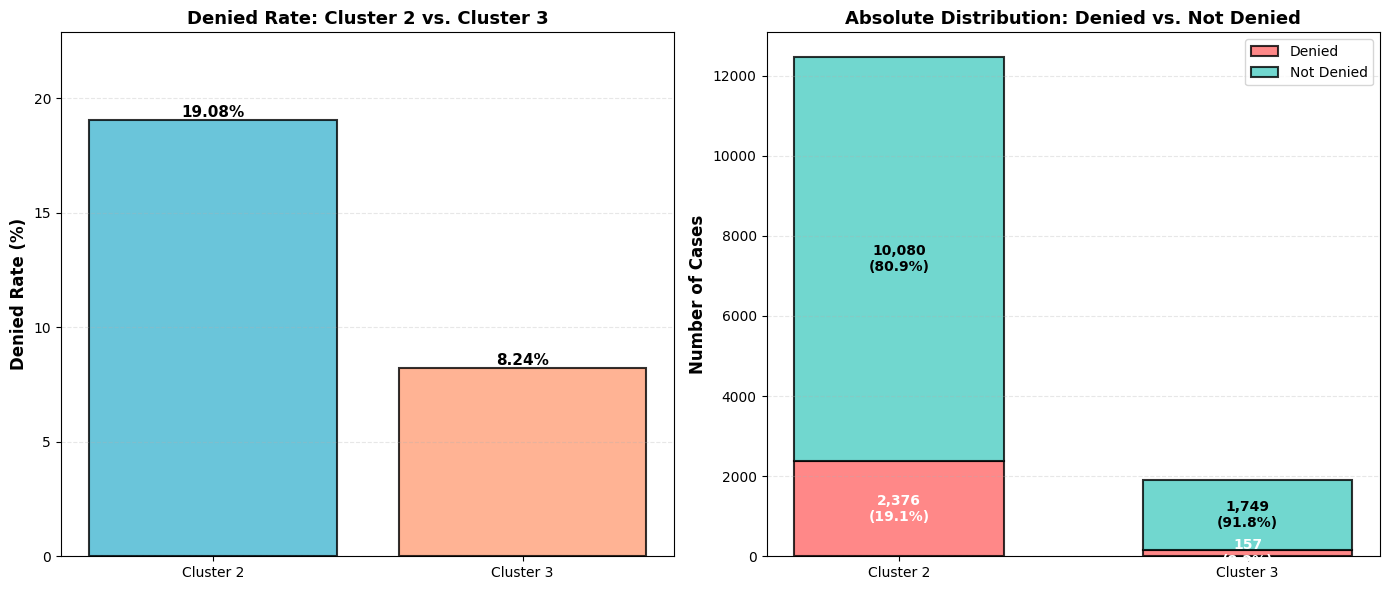

✓ Visualization created


In [ ]:
# Erstelle Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Bar Chart: Denied Rate in Prozent
clusters = ['Cluster 2', 'Cluster 3']
denied_rates = [denied_rate_2, denied_rate_3]
colors_bars = ['#45B7D1', '#FFA07A']

bars = axes[0].bar(clusters, denied_rates, color=colors_bars, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Denied Rate (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Denied Rate: Cluster 2 vs. Cluster 3', fontsize=13, fontweight='bold')
axes[0].set_ylim([0, max(denied_rates) * 1.2])
axes[0].grid(True, alpha=0.3, linestyle='--', axis='y')

# Füge Prozentwerte hinzu
for i, (bar, rate) in enumerate(zip(bars, denied_rates)):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{rate:.2f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Vergleich: Absolute Zahlen und Prozent
cluster_2_denied = cluster_2_data['is_denied'].sum()
cluster_3_denied = cluster_3_data['is_denied'].sum()
cluster_2_total = len(cluster_2_data)
cluster_3_total = len(cluster_3_data)

# Stacked Bar Chart: Denied vs. Not Denied
categories = ['Cluster 2', 'Cluster 3']
denied_counts = [cluster_2_denied, cluster_3_denied]
not_denied_counts = [cluster_2_total - cluster_2_denied, cluster_3_total - cluster_3_denied]

x = np.arange(len(categories))
width = 0.6

bars1 = axes[1].bar(x, denied_counts, width, label='Denied', color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = axes[1].bar(x, not_denied_counts, width, bottom=denied_counts, label='Not Denied', color='#4ECDC4', alpha=0.8, edgecolor='black', linewidth=1.5)

axes[1].set_ylabel('Number of Cases', fontsize=12, fontweight='bold')
axes[1].set_title('Absolute Distribution: Denied vs. Not Denied', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--', axis='y')

# Füge Labels über den Bars hinzu
for i, (d, nd) in enumerate(zip(denied_counts, not_denied_counts)):
    total = d + nd
    axes[1].text(i, d/2, f'{d:,}\n({d/total*100:.1f}%)',
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    axes[1].text(i, d + nd/2, f'{nd:,}\n({nd/total*100:.1f}%)',
                ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

